# Basic

In [524]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

import os
import pickle

from sklearn.metrics import accuracy_score

print("Libraries Loaded")

Libraries Loaded


In [525]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [526]:
PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

print("Project Path Set")

Project Path Set


In [527]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

In [528]:
X_test_phish = np.load(os.path.join(PROJECT_ROOT,"data/X_test_phish.npy"))
X_test_ids = np.load(os.path.join(PROJECT_ROOT,"data/X_test_ids.npy"))
X_test_fraud = np.load(os.path.join(PROJECT_ROOT,"data/X_test_fraud.npy"))

print("Test Data Loaded")

Test Data Loaded


In [529]:
xgb_phish = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/xgb_phish.pkl")
)

xgb_ids = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/xgb_ids.pkl")
)

xgb_fraud = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/xgb_fraud.pkl")
)

print("Models Loaded")

Models Loaded


In [530]:
feature_phish = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_phish.pkl")
)

feature_ids = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_ids.pkl")
)

feature_fraud = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_fraud.pkl")
)

print("Features Loaded")

Features Loaded


# XGBoost with Phishing

## Attack 1: Feature Perturbation Attack

In [531]:
sample_index = 0

original_sample = X_test_phish[sample_index].copy()

print("Original Prediction:",
      xgb_phish.predict(
          original_sample.reshape(1,-1)
      )[0])

Original Prediction: 1


In [532]:
perturbed_sample = original_sample.copy()

# perturb few important features
perturbed_sample[21] += 0.05   # IsHTTPS
perturbed_sample[22] += 0.05   # LineOfCode
perturbed_sample[8]  += 0.05   # NoOfSubDomain

print("Perturbed Prediction:",
      xgb_phish.predict(
          perturbed_sample.reshape(1,-1)
      )[0])

Perturbed Prediction: 1


In [533]:
original_prob = xgb_phish.predict_proba(
    original_sample.reshape(1,-1)
)

perturbed_prob = xgb_phish.predict_proba(
    perturbed_sample.reshape(1,-1)
)

print("Original Prob:", original_prob)
print("Perturbed Prob:", perturbed_prob)

Original Prob: [[3.2424927e-05 9.9996758e-01]]
Perturbed Prob: [[3.2424927e-05 9.9996758e-01]]


In [534]:
df_compare = pd.DataFrame({
    "Feature": feature_phish,
    "Original": original_sample,
    "Perturbed": perturbed_sample
})

df_compare[df_compare["Original"] != df_compare["Perturbed"]]

,Feature,Original,Perturbed
8,NoOfSubDomain,-0.274154,-0.224154
21,IsHTTPS,0.527021,0.577021
22,LineOfCode,-0.047925,0.002075


In [535]:
np.save(
    os.path.join(
        PROJECT_ROOT,
        "attacks",
        "phish_perturbed.npy"
    ),
    perturbed_sample
)

print("Perturbed sample saved")

Perturbed sample saved


In [536]:
import shap

explainer = shap.TreeExplainer(xgb_phish)

shap_original = explainer.shap_values(
    original_sample.reshape(1,-1)
)

shap_original = np.abs(shap_original[0])

shap_table_original = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": shap_original
})

shap_table_original = shap_table_original.sort_values(
    by="Importance",
    ascending=False
)

shap_table_original.head(10)

,Feature,Importance
47,NoOfSelfRef,2.961294
22,LineOfCode,2.002740
44,NoOfImage,0.860069
49,NoOfExternalRef,0.791847
36,HasSocialNet,0.625974
32,HasDescription,0.458600
19,NoOfOtherSpecialCharsInURL,0.442415
46,NoOfJS,0.396352
13,LetterRatioInURL,0.378735
21,IsHTTPS,0.361036


In [537]:
shap_perturbed = explainer.shap_values(
    perturbed_sample.reshape(1,-1)
)

shap_perturbed = np.abs(shap_perturbed[0])

shap_table_perturbed = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": shap_perturbed
})

shap_table_perturbed = shap_table_perturbed.sort_values(
    by="Importance",
    ascending=False
)

shap_table_perturbed.head(10)

,Feature,Importance
47,NoOfSelfRef,2.672750
22,LineOfCode,2.221775
44,NoOfImage,0.856522
49,NoOfExternalRef,0.791579
36,HasSocialNet,0.604334
32,HasDescription,0.458600
19,NoOfOtherSpecialCharsInURL,0.442709
46,NoOfJS,0.411017
13,LetterRatioInURL,0.376637
21,IsHTTPS,0.361036


In [538]:
comparison = pd.DataFrame({
    "Feature": feature_phish,
    "Before": shap_original,
    "After": shap_perturbed
})

comparison["Drift"] = np.abs(
    comparison["Before"] - comparison["After"]
)

comparison = comparison.sort_values(
    by="Drift",
    ascending=False
)

comparison.head(15)

,Feature,Before,After,Drift
47,NoOfSelfRef,2.961294,2.672750,0.288544
22,LineOfCode,2.002740,2.221775,0.219035
23,LargestLineLength,0.356646,0.278107,0.078539
36,HasSocialNet,0.625974,0.604334,0.021640
46,NoOfJS,0.396352,0.411017,0.014664
20,SpacialCharRatioInURL,0.081532,0.088889,0.007357
45,NoOfCSS,0.169531,0.164653,0.004878
44,NoOfImage,0.860069,0.856522,0.003547
13,LetterRatioInURL,0.378735,0.376637,0.002098
7,TLDLength,0.015857,0.015105,0.000752


/tmp/ipykernel_22688/679303094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


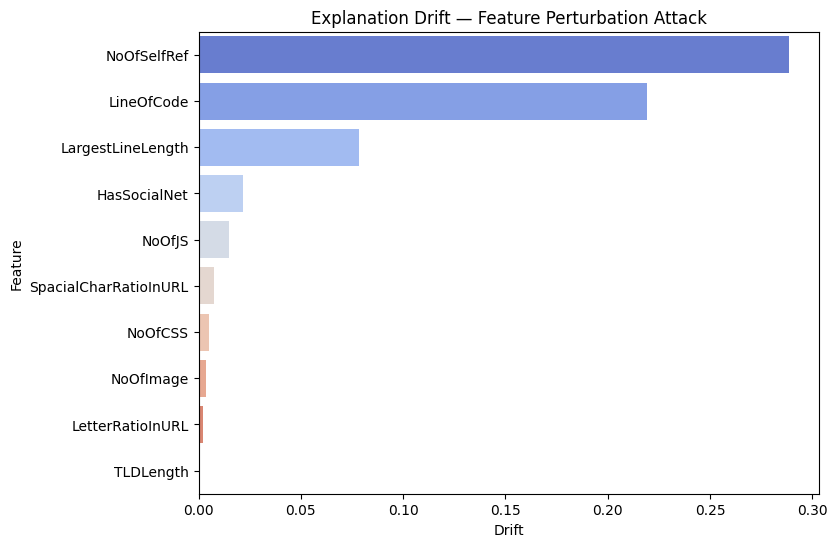

In [539]:
top_drift = comparison.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_drift,
    x="Drift",
    y="Feature",
    palette="coolwarm"
)

plt.title("Explanation Drift — Feature Perturbation Attack")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","Attack1_Drift_Phishing.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [540]:
print("Original Prob:", original_prob)
print("Perturbed Prob:", perturbed_prob)

print("Prediction Change:",
      np.abs(original_prob - perturbed_prob))

Original Prob: [[3.2424927e-05 9.9996758e-01]]
Perturbed Prob: [[3.2424927e-05 9.9996758e-01]]
Prediction Change: [[0. 0.]]


In [541]:
comparison.to_csv(
    os.path.join(
        PROJECT_ROOT,
        "attacks",
        "Attack1_Drift_Phishing.csv"
    ),
    index=False
)

print("Drift results saved")

Drift results saved


In [542]:
# Mean Drift
mean_drift = comparison["Drift"].mean()

# Max Drift
max_drift = comparison["Drift"].max()

# Top 5 Mean Drift
top5_drift = comparison.head(5)["Drift"].mean()

print("Mean Drift:", mean_drift)
print("Max Drift:", max_drift)
print("Top-5 Drift:", top5_drift)

Mean Drift: 0.012839015
Max Drift: 0.2885439395904541
Top-5 Drift: 0.124484494


## Attack 2 — Prediction-Stable Explanation Manipulation Attack

In [543]:
perturbed_sample_2 = original_sample.copy()

# perturb low-importance features
perturbed_sample_2[5]  += 0.10   # TLDLegitimateProb
perturbed_sample_2[0]  += 0.10   # URLLength
perturbed_sample_2[14] += 0.10   # NoOfDigitsInURL

print("Prediction After Attack 2:",
      xgb_phish.predict(
          perturbed_sample_2.reshape(1,-1)
      )[0])

Prediction After Attack 2: 1


In [544]:
perturbed_prob_2 = xgb_phish.predict_proba(
    perturbed_sample_2.reshape(1,-1)
)

print("Original:", original_prob)
print("Attack2 :", perturbed_prob_2)

Original: [[3.2424927e-05 9.9996758e-01]]
Attack2 : [[4.3153763e-05 9.9995685e-01]]


In [545]:
shap_attack2 = explainer.shap_values(
    perturbed_sample_2.reshape(1,-1)
)

shap_attack2 = np.abs(shap_attack2[0])

shap_table_attack2 = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": shap_attack2
})

shap_table_attack2 = shap_table_attack2.sort_values(
    by="Importance",
    ascending=False
)

shap_table_attack2.head(10)

,Feature,Importance
47,NoOfSelfRef,3.275439
22,LineOfCode,1.969318
44,NoOfImage,0.874014
49,NoOfExternalRef,0.812247
36,HasSocialNet,0.703012
19,NoOfOtherSpecialCharsInURL,0.513863
14,NoOfDegitsInURL,0.487705
32,HasDescription,0.420833
46,NoOfJS,0.391690
13,LetterRatioInURL,0.380604


In [546]:
comparison_attack2 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": shap_original,
    "After": shap_attack2
})

comparison_attack2["Drift"] = np.abs(
    comparison_attack2["Before"] - comparison_attack2["After"]
)

comparison_attack2 = comparison_attack2.sort_values(
    by="Drift",
    ascending=False
)

comparison_attack2.head(15)

,Feature,Before,After,Drift
47,NoOfSelfRef,2.961294,3.275439,0.314145
14,NoOfDegitsInURL,0.194639,0.487705,0.293066
36,HasSocialNet,0.625974,0.703012,0.077038
19,NoOfOtherSpecialCharsInURL,0.442415,0.513863,0.071448
32,HasDescription,0.458600,0.420833,0.037767
22,LineOfCode,2.002740,1.969318,0.033422
25,DomainTitleMatchScore,0.100806,0.123537,0.022731
49,NoOfExternalRef,0.791847,0.812247,0.020400
21,IsHTTPS,0.361036,0.345856,0.015180
44,NoOfImage,0.860069,0.874014,0.013945


/tmp/ipykernel_22688/1802294968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


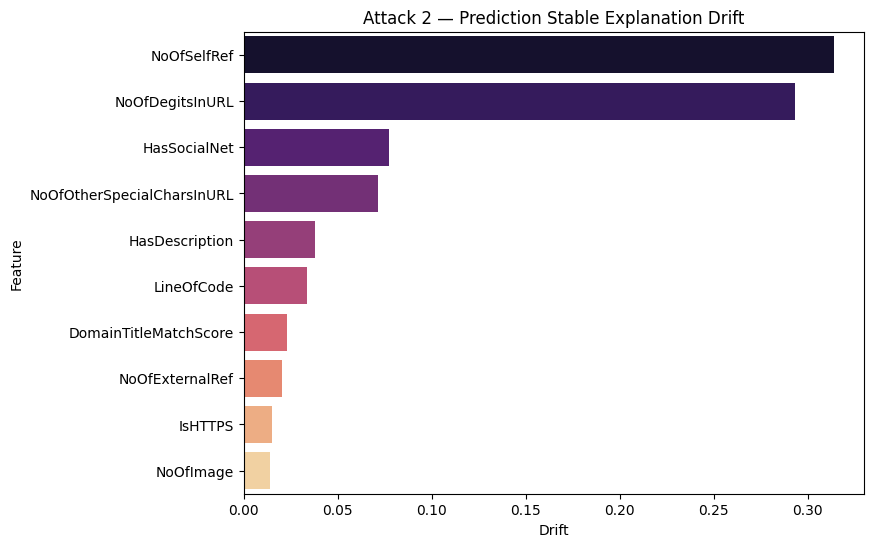

In [547]:
top_drift2 = comparison_attack2.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_drift2,
    x="Drift",
    y="Feature",
    palette="magma"
)

plt.title("Attack 2 — Prediction Stable Explanation Drift")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","Attack2_Drift_Phishing.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [548]:
comparison_attack2.to_csv(
    os.path.join(
        PROJECT_ROOT,
        "attacks",
        "Attack2_Drift_Phishing.csv"
    ),
    index=False
)

print("Attack 2 saved")

Attack 2 saved


In [549]:
print("Original:", original_prob)
print("Attack2 :", perturbed_prob_2)

print("Prediction Drift:",
      np.abs(original_prob - perturbed_prob_2))

Original: [[3.2424927e-05 9.9996758e-01]]
Attack2 : [[4.3153763e-05 9.9995685e-01]]
Prediction Drift: [[1.0728836e-05 1.0728836e-05]]


In [550]:
mean_drift2 = comparison_attack2["Drift"].mean()
max_drift2 = comparison_attack2["Drift"].max()
top5_drift2 = comparison_attack2.head(5)["Drift"].mean()

print("Attack2 Mean Drift:", mean_drift2)
print("Attack2 Max Drift:", max_drift2)
print("Attack2 Top-5 Drift:", top5_drift2)

Attack2 Mean Drift: 0.019402426
Attack2 Max Drift: 0.3141446113586426
Attack2 Top-5 Drift: 0.15869267


## Attack 3: Gradient-Based Explanation Attack

In [551]:
import torch
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [552]:
nn_phish = MLP(X_test_phish.shape[1])

nn_phish.load_state_dict(
    torch.load(
        os.path.join(
            PROJECT_ROOT,
            "models/base_models/nn_phish.pt"
        )
    )
)

nn_phish.eval()

print("Neural Model Loaded")

Neural Model Loaded


In [553]:
original_sample_tensor = torch.tensor(
    original_sample.reshape(1,-1),
    dtype=torch.float32,
    requires_grad=True
)

In [554]:
output = nn_phish(original_sample_tensor)

output.backward()

gradients = original_sample_tensor.grad.detach().numpy()[0]

grad_table = pd.DataFrame({
    "Feature": feature_phish,
    "Gradient": np.abs(gradients)
})

grad_table = grad_table.sort_values(
    by="Gradient",
    ascending=False
)

grad_table.head(10)

,Feature,Gradient
21,IsHTTPS,0.019685
19,NoOfOtherSpecialCharsInURL,0.015375
32,HasDescription,0.014302
43,HasCopyrightInfo,0.013745
20,SpacialCharRatioInURL,0.012934
15,DegitRatioInURL,0.012708
24,HasTitle,0.011854
29,IsResponsive,0.011405
13,LetterRatioInURL,0.010949
36,HasSocialNet,0.010914


In [555]:
# Get top gradient features
top_features = grad_table.head(3)["Feature"].values

print("Top Gradient Features:", top_features)

perturbed_sample_3 = original_sample.copy()

for feature in top_features:

    idx = feature_phish.index(feature)

    perturbed_sample_3[idx] += 0.05

print("Prediction Attack3:",
      xgb_phish.predict(
          perturbed_sample_3.reshape(1,-1)
      )[0])

Top Gradient Features: ['IsHTTPS' 'NoOfOtherSpecialCharsInURL' 'HasDescription']
Prediction Attack3: 1


In [556]:
df_attack3 = pd.DataFrame({
    "Feature": feature_phish,
    "Original": original_sample,
    "Perturbed": perturbed_sample_3
})

df_attack3[df_attack3["Original"] != df_attack3["Perturbed"]]

,Feature,Original,Perturbed
19,NoOfOtherSpecialCharsInURL,-0.379918,-0.329918
21,IsHTTPS,0.527021,0.577021
32,HasDescription,1.127733,1.177733


In [557]:
perturbed_prob_3 = xgb_phish.predict_proba(
    perturbed_sample_3.reshape(1,-1)
)

print("Original:", original_prob)
print("Attack3 :", perturbed_prob_3)

prediction_drift3 = np.abs(
    original_prob - perturbed_prob_3
).mean()

print("Prediction Drift:", prediction_drift3)

Original: [[3.2424927e-05 9.9996758e-01]]
Attack3 : [[3.2424927e-05 9.9996758e-01]]
Prediction Drift: 0.0


In [558]:
!pip install captum

In [559]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(nn_phish)

input_tensor = torch.tensor(
    original_sample.reshape(1,-1),
    dtype=torch.float32
)

attr_before, _ = ig.attribute(
    input_tensor,
    return_convergence_delta=True
)

attr_before = np.abs(attr_before.detach().numpy()[0])

In [560]:
input_tensor_attack = torch.tensor(
    perturbed_sample_3.reshape(1,-1),
    dtype=torch.float32
)

attr_after, _ = ig.attribute(
    input_tensor_attack,
    return_convergence_delta=True
)

attr_after = np.abs(attr_after.detach().numpy()[0])

In [561]:
comparison_attack3 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before,
    "After": attr_after
})

comparison_attack3["Drift"] = np.abs(
    comparison_attack3["Before"] -
    comparison_attack3["After"]
)

comparison_attack3 = comparison_attack3.sort_values(
    by="Drift",
    ascending=False
)

comparison_attack3.head(15)

,Feature,Before,After,Drift
21,IsHTTPS,0.031881,0.034590,0.002709
19,NoOfOtherSpecialCharsInURL,0.016283,0.014190,0.002093
43,HasCopyrightInfo,0.042512,0.041515,0.000997
32,HasDescription,0.046785,0.047702,0.000917
6,URLCharProb,0.022582,0.021695,0.000888
27,HasFavicon,0.021192,0.020601,0.000591
37,HasSubmitButton,0.018380,0.018964,0.000584
28,Robots,0.013389,0.012867,0.000522
4,CharContinuationRate,0.017413,0.016899,0.000514
36,HasSocialNet,0.037859,0.037428,0.000431


/tmp/ipykernel_22688/941080381.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


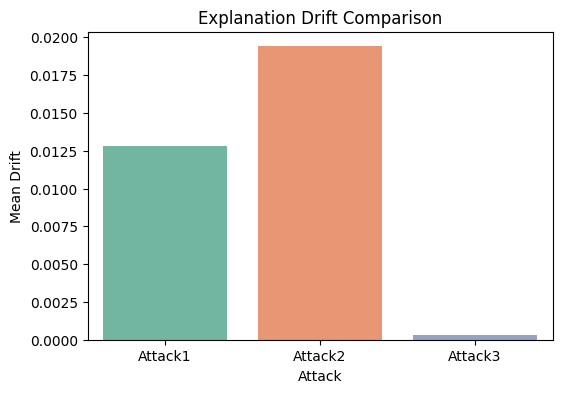

In [562]:
attack_compare = pd.DataFrame({
    "Attack": ["Attack1","Attack2","Attack3"],
    "Mean Drift": [
        mean_drift,
        mean_drift2,
        comparison_attack3["Drift"].mean()
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=attack_compare,
    x="Attack",
    y="Mean Drift",
    palette="Set2"
)

plt.title("Explanation Drift Comparison")

plt.show()

plt.savefig(
    os.path.join(
        PROJECT_ROOT,
        "figures",
        "Attack_Comparison.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## Attack 4 — Targeted Explanation Attack

In [563]:
# Get top features from original SHAP explanation
target_features = shap_table_original.head(3)["Feature"].values

print("Target Features for Attack 4:", target_features)

Target Features for Attack 4: ['NoOfSelfRef' 'LineOfCode' 'NoOfImage']


In [564]:
perturbed_sample_4 = original_sample.copy()

for feature in target_features:

    idx = feature_phish.index(feature)

    perturbed_sample_4[idx] += 0.15   # stronger perturbation

print("Prediction Attack4:",
      xgb_phish.predict(
          perturbed_sample_4.reshape(1,-1)
      )[0])

Prediction Attack4: 1


In [565]:
perturbed_prob_4 = xgb_phish.predict_proba(
    perturbed_sample_4.reshape(1,-1)
)

print("Original:", original_prob)
print("Attack4 :", perturbed_prob_4)

prediction_drift4 = np.abs(
    original_prob - perturbed_prob_4
).mean()

print("Prediction Drift:", prediction_drift4)

Original: [[3.2424927e-05 9.9996758e-01]]
Attack4 : [[3.2424927e-05 9.9996758e-01]]
Prediction Drift: 0.0


In [566]:
shap_attack4 = explainer.shap_values(
    perturbed_sample_4.reshape(1,-1)
)

shap_attack4 = np.abs(shap_attack4[0])

In [567]:
comparison_attack4 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": shap_original,
    "After": shap_attack4
})

comparison_attack4["Drift"] = np.abs(
    comparison_attack4["Before"] -
    comparison_attack4["After"]
)

comparison_attack4 = comparison_attack4.sort_values(
    by="Drift",
    ascending=False
)

comparison_attack4.head(15)

,Feature,Before,After,Drift
47,NoOfSelfRef,2.961294,2.629334,0.331960
22,LineOfCode,2.002740,2.241983,0.239243
44,NoOfImage,0.860069,1.062448,0.202378
49,NoOfExternalRef,0.791847,0.742800,0.049047
36,HasSocialNet,0.625974,0.580206,0.045768
32,HasDescription,0.458600,0.421758,0.036842
23,LargestLineLength,0.356646,0.320162,0.036483
43,HasCopyrightInfo,0.231712,0.213435,0.018277
46,NoOfJS,0.396352,0.411502,0.015150
20,SpacialCharRatioInURL,0.081532,0.088893,0.007361


/tmp/ipykernel_22688/2289792086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


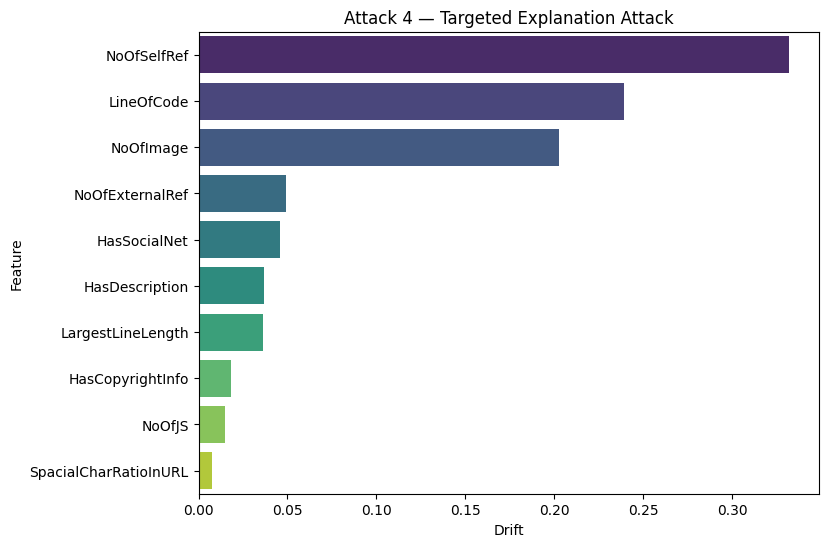

In [568]:
top_drift4 = comparison_attack4.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_drift4,
    x="Drift",
    y="Feature",
    palette="viridis"
)

plt.title("Attack 4 — Targeted Explanation Attack")

plt.show()

plt.savefig(
    os.path.join(
        PROJECT_ROOT,
        "figures",
        "Attack4_Targeted.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [569]:
mean_drift4 = comparison_attack4["Drift"].mean()
max_drift4 = comparison_attack4["Drift"].max()

print("Attack4 Mean Drift:", mean_drift4)
print("Attack4 Max Drift:", max_drift4)

Attack4 Mean Drift: 0.020068025
Attack4 Max Drift: 0.33196020126342773


/tmp/ipykernel_22688/1915974242.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


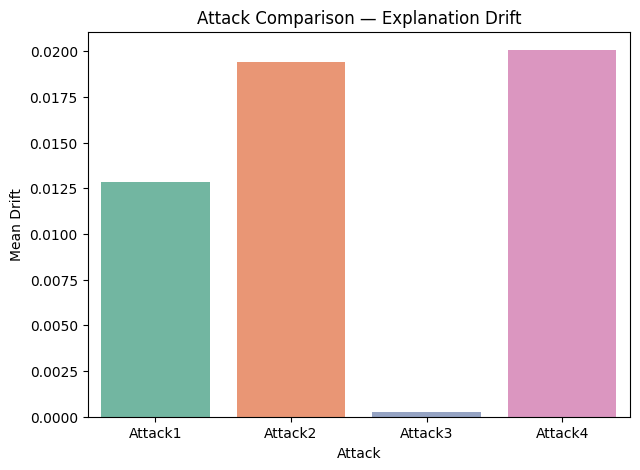

In [570]:
attack_compare = pd.DataFrame({
    "Attack": ["Attack1","Attack2","Attack3","Attack4"],
    "Mean Drift": [
        mean_drift,
        mean_drift2,
        comparison_attack3["Drift"].mean(),
        mean_drift4
    ]
})

plt.figure(figsize=(7,5))

sns.barplot(
    data=attack_compare,
    x="Attack",
    y="Mean Drift",
    palette="Set2"
)

plt.title("Attack Comparison — Explanation Drift")

plt.show()

plt.savefig(
    os.path.join(
        PROJECT_ROOT,
        "figures",
        "All_Attack_Comparison.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# XGBoost + IDS

In [571]:
# 2.0.1 — Load XGBoost IDS Model

xgb_ids = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "models/base_models/xgb_ids.pkl"
    )
)

print("XGBoost IDS Loaded")

XGBoost IDS Loaded


In [572]:
# 2.0.2 — Create SHAP Explainer for IDS

explainer_ids = shap.TreeExplainer(xgb_ids)

print("IDS SHAP Explainer Created")

IDS SHAP Explainer Created


In [573]:
# 2.0.3 — Select IDS Sample

sample_index = 0

original_ids = X_test_ids[sample_index].copy()

print("Original Prediction:",
      xgb_ids.predict(
          original_ids.reshape(1,-1)
      )[0])

Original Prediction: 1


## Attack 1

In [574]:
# 2.1.1 — SHAP Before Attack

shap_ids_before = explainer_ids.shap_values(
    original_ids.reshape(1,-1)
)

shap_ids_before = np.abs(shap_ids_before[0])

shap_ids_table = pd.DataFrame({
    "Feature": feature_ids,
    "Importance": shap_ids_before
})

shap_ids_table = shap_ids_table.sort_values(
    by="Importance",
    ascending=False
)

shap_ids_table.head(10)

,Feature,Importance
5,ip_reputation_score,6.139165
6,failed_logins,0.563310
2,login_attempts,0.427281
0,network_packet_size,0.228015
3,session_duration,0.088684
4,encryption_used,0.046748
7,browser_type,0.029873
1,protocol_type,0.023489
8,unusual_time_access,0.003754


In [575]:
# 2.1.2 — Perturb Top Features

perturbed_ids_1 = original_ids.copy()

top_features_ids = shap_ids_table.head(3)["Feature"].values

for feature in top_features_ids:

    idx = feature_ids.index(feature)

    perturbed_ids_1[idx] += 1

print("Prediction After Attack1:",
      xgb_ids.predict(
          perturbed_ids_1.reshape(1,-1)
      )[0])

Prediction After Attack1: 1


In [576]:
# 2.1.3 — SHAP After Attack

shap_ids_after = explainer_ids.shap_values(
    perturbed_ids_1.reshape(1,-1)
)

shap_ids_after = np.abs(shap_ids_after[0])

In [577]:
# 2.1.4 — Drift Table

comparison_ids_1 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": shap_ids_before,
    "After": shap_ids_after
})

comparison_ids_1["Drift"] = np.abs(
    comparison_ids_1["Before"] -
    comparison_ids_1["After"]
)

comparison_ids_1 = comparison_ids_1.sort_values(
    by="Drift",
    ascending=False
)

comparison_ids_1.head(15)

,Feature,Before,After,Drift
2,login_attempts,0.427281,0.128465,0.298817
6,failed_logins,0.563310,0.330079,0.233230
0,network_packet_size,0.228015,0.003259,0.224756
7,browser_type,0.029873,0.070314,0.040442
3,session_duration,0.088684,0.126073,0.037389
5,ip_reputation_score,6.139165,6.172487,0.033322
4,encryption_used,0.046748,0.030328,0.016420
1,protocol_type,0.023489,0.035202,0.011713
8,unusual_time_access,0.003754,0.003754,0.000000


In [578]:
# 2.1.5 — Drift Score

mean_drift_ids_1 = comparison_ids_1["Drift"].mean()

print("IDS Attack1 Drift:", mean_drift_ids_1)

IDS Attack1 Drift: 0.09956545


## Attack - 2

In [579]:
# 2.2.1 — Select Low Importance Features

low_features = shap_ids_table.tail(3)["Feature"].values

print("Low Features:", low_features)

Low Features: ['browser_type' 'protocol_type' 'unusual_time_access']


In [580]:
# 2.2.2 — Perturb Low Features

perturbed_ids_2 = original_ids.copy()

for feature in low_features:

    idx = feature_ids.index(feature)

    perturbed_ids_2[idx] += 1.1

In [581]:
# 2.2.3 — SHAP After Attack2

shap_ids_after2 = explainer_ids.shap_values(
    perturbed_ids_2.reshape(1,-1)
)

shap_ids_after2 = np.abs(shap_ids_after2[0])

In [582]:
# 2.2.4 — Drift Table

comparison_ids_2 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": shap_ids_before,
    "After": shap_ids_after2
})

comparison_ids_2["Drift"] = np.abs(
    comparison_ids_2["Before"] -
    comparison_ids_2["After"]
)

comparison_ids_2 = comparison_ids_2.sort_values(
    by="Drift",
    ascending=False
)

comparison_ids_2.head(15)

,Feature,Before,After,Drift
7,browser_type,0.029873,0.660522,0.630649
2,login_attempts,0.427281,0.855180,0.427898
5,ip_reputation_score,6.139165,5.726753,0.412412
6,failed_logins,0.563310,0.540690,0.022620
3,session_duration,0.088684,0.070279,0.018405
0,network_packet_size,0.228015,0.233146,0.005130
1,protocol_type,0.023489,0.022159,0.001330
8,unusual_time_access,0.003754,0.003187,0.000568
4,encryption_used,0.046748,0.046520,0.000228


In [583]:
# 2.2.5 — Drift Score

mean_drift_ids_2 = comparison_ids_2["Drift"].mean()

print("IDS Attack2 Drift:", mean_drift_ids_2)

IDS Attack2 Drift: 0.16880439


## Attack - 3

In [584]:
# 2.3.1 — Gradient Style Perturbation

perturbed_ids_3 = original_ids.copy()

top_grad = shap_ids_table.head(3)["Feature"].values

for feature in top_grad:

    idx = feature_ids.index(feature)

    perturbed_ids_3[idx] += 0.51

In [585]:
# 2.3.2 — SHAP After Attack3

shap_ids_after3 = explainer_ids.shap_values(
    perturbed_ids_3.reshape(1,-1)
)

shap_ids_after3 = np.abs(shap_ids_after3[0])

In [586]:
# 2.3.3 — Drift Table

comparison_ids_3 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": shap_ids_before,
    "After": shap_ids_after3
})

comparison_ids_3["Drift"] = np.abs(
    comparison_ids_3["Before"] -
    comparison_ids_3["After"]
)

comparison_ids_3 = comparison_ids_3.sort_values(
    by="Drift",
    ascending=False
)

comparison_ids_3.head(15)

,Feature,Before,After,Drift
2,login_attempts,0.427281,0.176200,0.251082
0,network_packet_size,0.228015,0.149558,0.078457
6,failed_logins,0.563310,0.608728,0.045418
7,browser_type,0.029873,0.074948,0.045075
3,session_duration,0.088684,0.124876,0.036192
1,protocol_type,0.023489,0.035202,0.011713
5,ip_reputation_score,6.139165,6.145863,0.006698
4,encryption_used,0.046748,0.040155,0.006593
8,unusual_time_access,0.003754,0.003754,0.000000


In [587]:
# 2.4.1 — Target Features

target_ids = shap_ids_table.head(3)["Feature"].values

print("Target IDS Features:", target_ids)

Target IDS Features: ['ip_reputation_score' 'failed_logins' 'login_attempts']


In [588]:
# 2.4.2 — Perturb Target Features

perturbed_ids_4 = original_ids.copy()

for feature in target_ids:

    idx = feature_ids.index(feature)

    perturbed_ids_4[idx] += 0.51

In [589]:
# 2.4.3 — SHAP After Attack4

shap_ids_after4 = explainer_ids.shap_values(
    perturbed_ids_4.reshape(1,-1)
)

shap_ids_after4 = np.abs(shap_ids_after4[0])

In [590]:
# 2.4.4 — Drift Table

comparison_ids_4 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": shap_ids_before,
    "After": shap_ids_after4
})

comparison_ids_4["Drift"] = np.abs(
    comparison_ids_4["Before"] -
    comparison_ids_4["After"]
)

comparison_ids_4 = comparison_ids_4.sort_values(
    by="Drift",
    ascending=False
)

comparison_ids_4.head(15)

,Feature,Before,After,Drift
2,login_attempts,0.427281,0.176200,0.251082
0,network_packet_size,0.228015,0.149558,0.078457
6,failed_logins,0.563310,0.608728,0.045418
7,browser_type,0.029873,0.074948,0.045075
3,session_duration,0.088684,0.124876,0.036192
1,protocol_type,0.023489,0.035202,0.011713
5,ip_reputation_score,6.139165,6.145863,0.006698
4,encryption_used,0.046748,0.040155,0.006593
8,unusual_time_access,0.003754,0.003754,0.000000


In [591]:
# 2.4.5 — Drift Score

mean_drift_ids_4 = comparison_ids_4["Drift"].mean()

print("IDS Attack4 Drift:", mean_drift_ids_4)

IDS Attack4 Drift: 0.053469714


#XGBoost + Fraud

In [592]:
# 3.0.1 — Load XGBoost Fraud Model

xgb_fraud = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "models/base_models/xgb_fraud.pkl"
    )
)

print("XGBoost Fraud Model Loaded")

XGBoost Fraud Model Loaded


In [593]:
# 3.0.2 — SHAP Explainer

explainer_fraud = shap.TreeExplainer(xgb_fraud)

print("Fraud SHAP Explainer Created")

Fraud SHAP Explainer Created


In [594]:
# 3.0.3 — Select Fraud Sample

sample_index = 0

original_fraud = X_test_fraud[sample_index].copy()

print("Original Prediction:",
      xgb_fraud.predict(
          original_fraud.reshape(1,-1)
      )[0])

Original Prediction: 1


In [595]:
# 3.0 — Setup (XGBoost + Fraud)

xgb_fraud = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "models/base_models/xgb_fraud.pkl"
    )
)

explainer_fraud = shap.TreeExplainer(xgb_fraud)

sample_index = 0
original_fraud = X_test_fraud[sample_index].copy()

print("Original Prediction:",
      xgb_fraud.predict(
          original_fraud.reshape(1,-1)
      )[0])

Original Prediction: 1


## Attack 1

In [596]:
# 3.1 — Attack 1 (Important Feature Perturbation)

# SHAP before
shap_before = explainer_fraud.shap_values(
    original_fraud.reshape(1,-1)
)
shap_before = np.abs(shap_before[0])

shap_table = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": shap_before
}).sort_values("Importance", ascending=False)

# Perturb
perturbed = original_fraud.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 1.19

# Prediction comparison
orig_pred = xgb_fraud.predict(original_fraud.reshape(1,-1))[0]
pert_pred = xgb_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = xgb_fraud.predict_proba(original_fraud.reshape(1,-1))
pert_prob = xgb_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)
print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)

# SHAP after
shap_after = explainer_fraud.shap_values(
    perturbed.reshape(1,-1)
)
shap_after = np.abs(shap_after[0])

# Drift
comparison_fraud_1 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": shap_before,
    "After": shap_after
})

comparison_fraud_1["Drift"] = np.abs(
    comparison_fraud_1["Before"] -
    comparison_fraud_1["After"]
)

print("\nTop Drift Features")
display(
    comparison_fraud_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_fraud_1 = comparison_fraud_1["Drift"].mean()
print("\nAttack-1 Mean Drift:", mean_drift_fraud_1)

Original: 1
Perturbed: 1
Original Prob: [[0.00387192 0.9961281 ]]
Perturbed Prob: [[0.32904232 0.6709577 ]]

Top Drift Features


,Feature,Before,After,Drift
19,TrustPilot score,6.190844,2.315169,3.875675
17,Indication of young domain,0.720947,1.368456,0.647509
18,Presence of TrustPilot reviews,1.026923,1.353288,0.326365
8,Presence of money back payment,0.154526,0.184087,0.029560
5,Number of dots (.),0.225577,0.243199,0.017622
12,Presence of logo URL,0.025538,0.017340,0.008198
13,SSL certificate issuer,0.345296,0.350938,0.005642
2,Presence of prefix 'www',0.034733,0.037178,0.002445
11,Presence of free contact emails,0.098798,0.100734,0.001936
0,Domain length,0.068649,0.069672,0.001023



Attack-1 Mean Drift: 0.21383297


## Attack 2:

In [597]:
# 3.2 — Attack 2 (Low Importance Perturbation)

low_features = shap_table.tail(3)["Feature"].values

perturbed = original_fraud.copy()

for feature in low_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 164449495555

# Prediction
orig_pred = xgb_fraud.predict(original_fraud.reshape(1,-1))[0]
pert_pred = xgb_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = xgb_fraud.predict_proba(original_fraud.reshape(1,-1))
pert_prob = xgb_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)
print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)

# SHAP
shap_after = explainer_fraud.shap_values(
    perturbed.reshape(1,-1)
)
shap_after = np.abs(shap_after[0])

comparison_fraud_2 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": shap_before,
    "After": shap_after
})

comparison_fraud_2["Drift"] = np.abs(
    comparison_fraud_2["Before"] -
    comparison_fraud_2["After"]
)

print("\nTop Drift Features")
display(
    comparison_fraud_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_fraud_2 = comparison_fraud_2["Drift"].mean()
print("\nAttack-2 Mean Drift:", mean_drift_fraud_2)

Original: 1
Perturbed: 1
Original Prob: [[0.00387192 0.9961281 ]]
Perturbed Prob: [[0.00387192 0.9961281 ]]

Top Drift Features


,Feature,Before,After,Drift
0,Domain length,0.068649,0.068649,0.0
12,Presence of logo URL,0.025538,0.025538,0.0
21,Presence in the standard Tranco list,0.000000,0.000000,0.0
20,Presence of SiteJabber reviews,0.000000,0.000000,0.0
19,TrustPilot score,6.190844,6.190844,0.0
18,Presence of TrustPilot reviews,1.026923,1.026923,0.0
17,Indication of young domain,0.720947,0.720947,0.0
16,SSL certificate issuer organization list item,0.034516,0.034516,0.0
15,Issuer organization,0.101784,0.101784,0.0
14,SSL certificate expire date,0.195055,0.195055,0.0



Attack-2 Mean Drift: 0.0


## Attack 3:

In [598]:
# 3.1 — Attack 1 (Important Feature Perturbation)

# SHAP before
shap_before = explainer_fraud.shap_values(
    original_fraud.reshape(1,-1)
)
shap_before = np.abs(shap_before[0])

shap_table = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": shap_before
}).sort_values("Importance", ascending=False)

# Perturb
perturbed = original_fraud.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 1.19

# Prediction comparison
orig_pred = xgb_fraud.predict(original_fraud.reshape(1,-1))[0]
pert_pred = xgb_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = xgb_fraud.predict_proba(original_fraud.reshape(1,-1))
pert_prob = xgb_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)
print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)

# SHAP after
shap_after = explainer_fraud.shap_values(
    perturbed.reshape(1,-1)
)
shap_after = np.abs(shap_after[0])

# Drift
comparison_fraud_1 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": shap_before,
    "After": shap_after
})

comparison_fraud_1["Drift"] = np.abs(
    comparison_fraud_1["Before"] -
    comparison_fraud_1["After"]
)

print("\nTop Drift Features")
display(
    comparison_fraud_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_fraud_1 = comparison_fraud_1["Drift"].mean()
print("\nAttack-1 Mean Drift:", mean_drift_fraud_1)

Original: 1
Perturbed: 1
Original Prob: [[0.00387192 0.9961281 ]]
Perturbed Prob: [[0.32904232 0.6709577 ]]

Top Drift Features


,Feature,Before,After,Drift
19,TrustPilot score,6.190844,2.315169,3.875675
17,Indication of young domain,0.720947,1.368456,0.647509
18,Presence of TrustPilot reviews,1.026923,1.353288,0.326365
8,Presence of money back payment,0.154526,0.184087,0.029560
5,Number of dots (.),0.225577,0.243199,0.017622
12,Presence of logo URL,0.025538,0.017340,0.008198
13,SSL certificate issuer,0.345296,0.350938,0.005642
2,Presence of prefix 'www',0.034733,0.037178,0.002445
11,Presence of free contact emails,0.098798,0.100734,0.001936
0,Domain length,0.068649,0.069672,0.001023



Attack-1 Mean Drift: 0.21383297


## Attack 4:

In [599]:
# 3.4 — Attack 4 (Targeted Explanation Attack)

target_features = shap_table.head(3)["Feature"].values

perturbed = original_fraud.copy()

for feature in target_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 1.19

# Prediction
orig_pred = xgb_fraud.predict(original_fraud.reshape(1,-1))[0]
pert_pred = xgb_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = xgb_fraud.predict_proba(original_fraud.reshape(1,-1))
pert_prob = xgb_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)
print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)

# SHAP
shap_after = explainer_fraud.shap_values(
    perturbed.reshape(1,-1)
)
shap_after = np.abs(shap_after[0])

comparison_fraud_4 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": shap_before,
    "After": shap_after
})

comparison_fraud_4["Drift"] = np.abs(
    comparison_fraud_4["Before"] -
    comparison_fraud_4["After"]
)

print("\nTop Drift Features")
display(
    comparison_fraud_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_fraud_4 = comparison_fraud_4["Drift"].mean()
print("\nAttack-4 Mean Drift:", mean_drift_fraud_4)

Original: 1
Perturbed: 1
Original Prob: [[0.00387192 0.9961281 ]]
Perturbed Prob: [[0.32904232 0.6709577 ]]

Top Drift Features


,Feature,Before,After,Drift
19,TrustPilot score,6.190844,2.315169,3.875675
17,Indication of young domain,0.720947,1.368456,0.647509
18,Presence of TrustPilot reviews,1.026923,1.353288,0.326365
8,Presence of money back payment,0.154526,0.184087,0.029560
5,Number of dots (.),0.225577,0.243199,0.017622
12,Presence of logo URL,0.025538,0.017340,0.008198
13,SSL certificate issuer,0.345296,0.350938,0.005642
2,Presence of prefix 'www',0.034733,0.037178,0.002445
11,Presence of free contact emails,0.098798,0.100734,0.001936
0,Domain length,0.068649,0.069672,0.001023



Attack-4 Mean Drift: 0.21383297


# LR + Phishing

In [600]:
# 4.0 — Setup Logistic + Phishing

# Load Model
log_phish = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "models/base_models/logistic_phish.pkl"
    )
)

# Load Data
X_test_phish = np.load(
    os.path.join(PROJECT_ROOT,"data/X_test_phish.npy")
)

# Load Feature Names
feature_phish = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "data/feature_phish.pkl"
    )
)

# Select Sample
sample_index = 0
original = X_test_phish[sample_index].copy()

print("Original Prediction:",
      log_phish.predict(
          original.reshape(1,-1)
      )[0])

Original Prediction: 1


In [601]:
# 4.0.1 — SHAP Explainer Logistic

background = X_test_phish[:100]

explainer_log_phish = shap.KernelExplainer(
    log_phish.predict_proba,
    background
)

print("Logistic SHAP Explainer Created")

Logistic SHAP Explainer Created


In [602]:
# 4.1 — Attack-1 Logistic Phishing

# SHAP Before
shap_before = explainer_log_phish.shap_values(
    original.reshape(1,-1)
)

# Handle different SHAP outputs
if isinstance(shap_before, list):
    shap_before = shap_before[0]

shap_before = np.array(shap_before).reshape(-1)

# Ensure correct length
shap_before = shap_before[:len(feature_phish)]

# Create Table
shap_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": np.abs(shap_before)
}).sort_values("Importance", ascending=False)


# Perturb
perturbed = original.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_phish.index(feature)
    perturbed[idx] += 0.1


# Prediction Comparison
orig_pred = log_phish.predict(original.reshape(1,-1))[0]
pert_pred = log_phish.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_phish.predict_proba(original.reshape(1,-1))
pert_prob = log_phish.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP After
shap_after = explainer_log_phish.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_phish)]


# Drift
comparison_4_1 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_4_1["Drift"] = np.abs(
    comparison_4_1["Before"] -
    comparison_4_1["After"]
)

print("\nTop Drift Features")
display(
    comparison_4_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_4_1 = comparison_4_1["Drift"].mean()

print("\nAttack-1 Mean Drift:", mean_drift_4_1)

  0%|          | 0/1 [00:00<?, ?it/s]

Original: 1
Perturbed: 1
Original Prob: [[1.88832239e-09 9.99999998e-01]]
Perturbed Prob: [[1.68320824e-09 9.99999998e-01]]


  0%|          | 0/1 [00:00<?, ?it/s]


Top Drift Features


,Feature,Before,After,Drift
43,HasCopyrightInfo,0.087518,0.075649,0.011869
42,Crypto,0.087518,0.075649,0.011869
27,HasFavicon,0.046047,0.039356,0.006691
26,URLTitleMatchScore,0.046047,0.039356,0.006691
39,HasPasswordField,0.015570,0.020567,0.004997
38,HasHiddenFields,0.015570,0.020567,0.004997
31,NoOfSelfRedirect,0.042397,0.046640,0.004242
30,NoOfURLRedirect,0.042397,0.046640,0.004242
13,LetterRatioInURL,0.020185,0.018843,0.001342
12,NoOfLettersInURL,0.020185,0.018843,0.001342



Attack-1 Mean Drift: 0.0012016783893312394


In [603]:
# 4.2 — Attack-2 Logistic Phishing (Low Importance)

low_features = shap_table.tail(3)["Feature"].values

perturbed = original.copy()

for feature in low_features:
    idx = feature_phish.index(feature)
    perturbed[idx] += 0.2


# Prediction
orig_pred = log_phish.predict(original.reshape(1,-1))[0]
pert_pred = log_phish.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_phish.predict_proba(original.reshape(1,-1))
pert_prob = log_phish.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP After
shap_after = explainer_log_phish.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_phish)]


comparison_4_2 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_4_2["Drift"] = np.abs(
    comparison_4_2["Before"] -
    comparison_4_2["After"]
)

display(
    comparison_4_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_4_2 = comparison_4_2["Drift"].mean()

print("Attack-2 Mean Drift:", mean_drift_4_2)

Original: 1
Perturbed: 1
Original Prob: [[1.88832239e-09 9.99999998e-01]]
Perturbed Prob: [[1.01162101e-09 9.99999999e-01]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
39,HasPasswordField,0.015570,0.024840,0.009270
38,HasHiddenFields,0.015570,0.024840,0.009270
27,HasFavicon,0.046047,0.039976,0.006071
26,URLTitleMatchScore,0.046047,0.039976,0.006071
30,NoOfURLRedirect,0.042397,0.037269,0.005129
31,NoOfSelfRedirect,0.042397,0.037269,0.005129
43,HasCopyrightInfo,0.087518,0.083416,0.004102
42,Crypto,0.087518,0.083416,0.004102
13,LetterRatioInURL,0.020185,0.019202,0.000983
12,NoOfLettersInURL,0.020185,0.019202,0.000983


Attack-2 Mean Drift: 0.0010345202223076865


In [604]:
# 4.3 — Attack-3 Logistic Phishing

perturbed = original.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_phish.index(feature)
    perturbed[idx] += 0.3


# Prediction
orig_pred = log_phish.predict(original.reshape(1,-1))[0]
pert_pred = log_phish.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_phish.predict_proba(original.reshape(1,-1))
pert_prob = log_phish.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP
shap_after = explainer_log_phish.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_phish)]


comparison_4_3 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_4_3["Drift"] = np.abs(
    comparison_4_3["Before"] -
    comparison_4_3["After"]
)

display(
    comparison_4_3.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_4_3 = comparison_4_3["Drift"].mean()

print("Attack-3 Mean Drift:", mean_drift_4_3)

Original: 1
Perturbed: 1
Original Prob: [[1.88832239e-09 9.99999998e-01]]
Perturbed Prob: [[1.33739997e-09 9.99999999e-01]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
13,LetterRatioInURL,0.020185,0.000000,0.020185
12,NoOfLettersInURL,0.020185,0.000000,0.020185
43,HasCopyrightInfo,0.087518,0.077590,0.009928
42,Crypto,0.087518,0.077590,0.009928
27,HasFavicon,0.046047,0.050676,0.004629
26,URLTitleMatchScore,0.046047,0.050676,0.004629
31,NoOfSelfRedirect,0.042397,0.043956,0.001559
30,NoOfURLRedirect,0.042397,0.043956,0.001559
39,HasPasswordField,0.015570,0.016895,0.001325
38,HasHiddenFields,0.015570,0.016895,0.001325


Attack-3 Mean Drift: 0.0015300919050764


In [605]:
# 4.4 — Attack-4 Logistic Phishing

target_features = shap_table.head(3)["Feature"].values

perturbed = original.copy()

for feature in target_features:
    idx = feature_phish.index(feature)
    perturbed[idx] += 0.5


# Prediction
orig_pred = log_phish.predict(original.reshape(1,-1))[0]
pert_pred = log_phish.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_phish.predict_proba(original.reshape(1,-1))
pert_prob = log_phish.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP
shap_after = explainer_log_phish.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_phish)]


comparison_4_4 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_4_4["Drift"] = np.abs(
    comparison_4_4["Before"] -
    comparison_4_4["After"]
)

display(
    comparison_4_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_4_4 = comparison_4_4["Drift"].mean()

print("Attack-4 Mean Drift:", mean_drift_4_4)

Original: 1
Perturbed: 1
Original Prob: [[1.88832239e-09 9.99999998e-01]]
Perturbed Prob: [[1.06263665e-09 9.99999999e-01]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
13,LetterRatioInURL,0.020185,0.000000,0.020185
12,NoOfLettersInURL,0.020185,0.000000,0.020185
38,HasHiddenFields,0.015570,0.000000,0.015570
39,HasPasswordField,0.015570,0.000000,0.015570
43,HasCopyrightInfo,0.087518,0.075592,0.011926
42,Crypto,0.087518,0.075592,0.011926
41,Pay,0.066101,0.058473,0.007628
40,Bank,0.066101,0.058473,0.007628
26,URLTitleMatchScore,0.046047,0.043981,0.002066
27,HasFavicon,0.046047,0.043981,0.002066


Attack-4 Mean Drift: 0.0023049727180756365


# LR + IDS

In [606]:
# 5.0 — Setup Logistic + IDS

# Load Model
log_ids = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "models/base_models/logistic_ids.pkl"
    )
)

# Load Data
X_test_ids = np.load(
    os.path.join(PROJECT_ROOT,"data/X_test_ids.npy")
)

# Load Features
feature_ids = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "data/feature_ids.pkl"
    )
)

# Sample
sample_index = 0
original = X_test_ids[sample_index].copy()

# SHAP Explainer
background = X_test_ids[:100]

explainer_log_ids = shap.KernelExplainer(
    log_ids.predict_proba,
    background
)

print("Original Prediction:",
      log_ids.predict(
          original.reshape(1,-1)
      )[0])

Original Prediction: 0


In [607]:
# 5.1 — Attack-1 Logistic IDS

shap_before = explainer_log_ids.shap_values(
    original.reshape(1,-1)
)

if isinstance(shap_before, list):
    shap_before = shap_before[0]

shap_before = np.array(shap_before).reshape(-1)
shap_before = shap_before[:len(feature_ids)]

shap_table = pd.DataFrame({
    "Feature": feature_ids,
    "Importance": np.abs(shap_before)
}).sort_values("Importance", ascending=False)


perturbed = original.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_ids.index(feature)
    perturbed[idx] += 1


# Prediction
orig_pred = log_ids.predict(original.reshape(1,-1))[0]
pert_pred = log_ids.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_ids.predict_proba(original.reshape(1,-1))
pert_prob = log_ids.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)
print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP After
shap_after = explainer_log_ids.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_ids)]


comparison_5_1 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_5_1["Drift"] = np.abs(
    comparison_5_1["Before"] -
    comparison_5_1["After"]
)

display(
    comparison_5_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_5_1 = comparison_5_1["Drift"].mean()
print("Attack-1 Mean Drift:", mean_drift_5_1)

  0%|          | 0/1 [00:00<?, ?it/s]

Original: 0
Perturbed: 0
Original Prob: [[0.76364235 0.23635765]]
Perturbed Prob: [[0.62480797 0.37519203]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
5,ip_reputation_score,0.092069,0.090455,0.001614
4,encryption_used,0.092069,0.090455,0.001614
8,unusual_time_access,0.000125,0.001109,0.000983
6,failed_logins,0.016689,0.017553,0.000864
7,browser_type,0.016689,0.017553,0.000864
2,login_attempts,0.004364,0.004658,0.000294
3,session_duration,0.004364,0.004658,0.000294
0,network_packet_size,0.001164,0.001244,0.000080
1,protocol_type,0.001164,0.001244,0.000080


Attack-1 Mean Drift: 0.0007428253184418029


In [608]:
# 5.2 — Attack-2 Logistic IDS

low_features = shap_table.tail(3)["Feature"].values

perturbed = original.copy()

for feature in low_features:
    idx = feature_ids.index(feature)
    perturbed[idx] += 2


# Prediction
orig_pred = log_ids.predict(original.reshape(1,-1))[0]
pert_pred = log_ids.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_ids.predict_proba(original.reshape(1,-1))
pert_prob = log_ids.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP
shap_after = explainer_log_ids.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_ids)]


comparison_5_2 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_5_2["Drift"] = np.abs(
    comparison_5_2["Before"] -
    comparison_5_2["After"]
)

display(
    comparison_5_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_5_2 = comparison_5_2["Drift"].mean()
print("Attack-2 Mean Drift:", mean_drift_5_2)

Original: 0
Perturbed: 0
Original Prob: [[0.76364235 0.23635765]]
Perturbed Prob: [[0.75565472 0.24434528]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
2,login_attempts,0.004364,0.011909,7.544730e-03
3,session_duration,0.004364,0.011909,7.544730e-03
0,network_packet_size,0.001164,0.002556,1.392423e-03
1,protocol_type,0.001164,0.002556,1.392423e-03
4,encryption_used,0.092069,0.092308,2.392933e-04
5,ip_reputation_score,0.092069,0.092308,2.392933e-04
6,failed_logins,0.016689,0.016792,1.027173e-04
7,browser_type,0.016689,0.016792,1.027173e-04
8,unusual_time_access,0.000125,0.000126,6.341358e-07


Attack-2 Mean Drift: 0.002062106859650921


In [609]:
# 5.3 — Attack-3 Logistic IDS (Gradient Style)

perturbed = original.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_ids.index(feature)
    perturbed[idx] += 1


# Prediction
orig_pred = log_ids.predict(original.reshape(1,-1))[0]
pert_pred = log_ids.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_ids.predict_proba(original.reshape(1,-1))
pert_prob = log_ids.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP After
shap_after = explainer_log_ids.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_ids)]


comparison_5_3 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_5_3["Drift"] = np.abs(
    comparison_5_3["Before"] -
    comparison_5_3["After"]
)

display(
    comparison_5_3.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_5_3 = comparison_5_3["Drift"].mean()
print("Attack-3 Mean Drift:", mean_drift_5_3)

Original: 0
Perturbed: 0
Original Prob: [[0.76364235 0.23635765]]
Perturbed Prob: [[0.62480797 0.37519203]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
5,ip_reputation_score,0.092069,0.090455,0.001614
4,encryption_used,0.092069,0.090455,0.001614
8,unusual_time_access,0.000125,0.001109,0.000983
6,failed_logins,0.016689,0.017553,0.000864
7,browser_type,0.016689,0.017553,0.000864
2,login_attempts,0.004364,0.004658,0.000294
3,session_duration,0.004364,0.004658,0.000294
0,network_packet_size,0.001164,0.001244,0.000080
1,protocol_type,0.001164,0.001244,0.000080


Attack-3 Mean Drift: 0.0007428253184418029


In [610]:
# 5.4 — Attack-4 Logistic IDS (Targeted Attack)

target_features = shap_table.head(3)["Feature"].values

perturbed = original.copy()

for feature in target_features:
    idx = feature_ids.index(feature)
    perturbed[idx] += 1


# Prediction
orig_pred = log_ids.predict(original.reshape(1,-1))[0]
pert_pred = log_ids.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_ids.predict_proba(original.reshape(1,-1))
pert_prob = log_ids.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP After
shap_after = explainer_log_ids.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_ids)]


comparison_5_4 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_5_4["Drift"] = np.abs(
    comparison_5_4["Before"] -
    comparison_5_4["After"]
)

display(
    comparison_5_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_5_4 = comparison_5_4["Drift"].mean()
print("Attack-4 Mean Drift:", mean_drift_5_4)

Original: 0
Perturbed: 0
Original Prob: [[0.76364235 0.23635765]]
Perturbed Prob: [[0.62480797 0.37519203]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
5,ip_reputation_score,0.092069,0.090455,0.001614
4,encryption_used,0.092069,0.090455,0.001614
8,unusual_time_access,0.000125,0.001109,0.000983
6,failed_logins,0.016689,0.017553,0.000864
7,browser_type,0.016689,0.017553,0.000864
2,login_attempts,0.004364,0.004658,0.000294
3,session_duration,0.004364,0.004658,0.000294
0,network_packet_size,0.001164,0.001244,0.000080
1,protocol_type,0.001164,0.001244,0.000080


Attack-4 Mean Drift: 0.0007428253184418029


# LR + Fraud

In [611]:
# 6.0 — Setup Logistic + Fraud

# Load Model
log_fraud = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "models/base_models/logistic_fraud.pkl"
    )
)

# Load Data
X_test_fraud = np.load(
    os.path.join(PROJECT_ROOT,"data/X_test_fraud.npy")
)

# Load Features
feature_fraud = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "data/feature_fraud.pkl"
    )
)

# Sample
sample_index = 0
original = X_test_fraud[sample_index].copy()

# SHAP Explainer
background = X_test_fraud[:100]

explainer_log_fraud = shap.KernelExplainer(
    log_fraud.predict_proba,
    background
)

print("Original Prediction:",
      log_fraud.predict(
          original.reshape(1,-1)
      )[0])

Original Prediction: 1


In [612]:
# 6.1 — Attack-1 Logistic Fraud

shap_before = explainer_log_fraud.shap_values(
    original.reshape(1,-1)
)

if isinstance(shap_before, list):
    shap_before = shap_before[0]

shap_before = np.array(shap_before).reshape(-1)
shap_before = shap_before[:len(feature_fraud)]

shap_table = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": np.abs(shap_before)
}).sort_values("Importance", ascending=False)


perturbed = original.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 5


# Prediction
orig_pred = log_fraud.predict(original.reshape(1,-1))[0]
pert_pred = log_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_fraud.predict_proba(original.reshape(1,-1))
pert_prob = log_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


# SHAP
shap_after = explainer_log_fraud.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_fraud)]


comparison_6_1 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_6_1["Drift"] = np.abs(
    comparison_6_1["Before"] -
    comparison_6_1["After"]
)

display(
    comparison_6_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_6_1 = comparison_6_1["Drift"].mean()
print("Attack-1 Mean Drift:", mean_drift_6_1)

  0%|          | 0/1 [00:00<?, ?it/s]

Original: 1
Perturbed: 1
Original Prob: [[0.01037529 0.98962471]]
Perturbed Prob: [[0.01472921 0.98527079]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
22,Tranco List rank,0.000000,0.252932,0.252932
2,Presence of prefix 'www',0.037191,0.114727,0.077536
3,Number of digits,0.037191,0.114727,0.077536
20,Presence of SiteJabber reviews,0.000000,0.060645,0.060645
21,Presence in the standard Tranco list,0.000000,0.060645,0.060645
0,Domain length,0.061074,0.076543,0.015469
1,Top domain length,0.061074,0.076543,0.015469
11,Presence of free contact emails,0.074799,0.072825,0.001974
10,Presence of crypto currency,0.074799,0.072825,0.001974
4,Number of letters,0.051938,0.053246,0.001308


Attack-1 Mean Drift: 0.02464325506319948


In [613]:
# 6.2 — Attack-2 Logistic Fraud

low_features = shap_table.tail(3)["Feature"].values

perturbed = original.copy()

for feature in low_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 10


orig_pred = log_fraud.predict(original.reshape(1,-1))[0]
pert_pred = log_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_fraud.predict_proba(original.reshape(1,-1))
pert_prob = log_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


shap_after = explainer_log_fraud.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_fraud)]


comparison_6_2 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_6_2["Drift"] = np.abs(
    comparison_6_2["Before"] -
    comparison_6_2["After"]
)

display(
    comparison_6_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_6_2 = comparison_6_2["Drift"].mean()
print("Attack-2 Mean Drift:", mean_drift_6_2)

Original: 1
Perturbed: 1
Original Prob: [[0.01037529 0.98962471]]
Perturbed Prob: [[1.55836242e-04 9.99844164e-01]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
11,Presence of free contact emails,0.074799,0.000000,0.074799
10,Presence of crypto currency,0.074799,0.000000,0.074799
15,Issuer organization,0.000000,0.050291,0.050291
14,SSL certificate expire date,0.000000,0.050291,0.050291
12,Presence of logo URL,0.000000,0.032498,0.032498
13,SSL certificate issuer,0.000000,0.032498,0.032498
1,Top domain length,0.061074,0.042436,0.018638
0,Domain length,0.061074,0.042436,0.018638
3,Number of digits,0.037191,0.022697,0.014495
2,Presence of prefix 'www',0.037191,0.022697,0.014495


Attack-2 Mean Drift: 0.01782269613696891


In [614]:
# 6.3 — Attack-3 Logistic Fraud

perturbed = original.copy()

top_features = shap_table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 6


orig_pred = log_fraud.predict(original.reshape(1,-1))[0]
pert_pred = log_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_fraud.predict_proba(original.reshape(1,-1))
pert_prob = log_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


shap_after = explainer_log_fraud.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_fraud)]


comparison_6_3 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_6_3["Drift"] = np.abs(
    comparison_6_3["Before"] -
    comparison_6_3["After"]
)

display(
    comparison_6_3.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_6_3 = comparison_6_3["Drift"].mean()
print("Attack-3 Mean Drift:", mean_drift_6_3)

Original: 1
Perturbed: 1
Original Prob: [[0.01037529 0.98962471]]
Perturbed Prob: [[0.01579531 0.98420469]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
22,Tranco List rank,0.000000,0.325432,0.325432
2,Presence of prefix 'www',0.037191,0.152540,0.115348
3,Number of digits,0.037191,0.152540,0.115348
21,Presence in the standard Tranco list,0.000000,0.074991,0.074991
20,Presence of SiteJabber reviews,0.000000,0.074991,0.074991
0,Domain length,0.061074,0.069407,0.008332
1,Top domain length,0.061074,0.069407,0.008332
4,Number of letters,0.051938,0.058590,0.006652
5,Number of dots (.),0.051938,0.058590,0.006652
10,Presence of crypto currency,0.074799,0.075270,0.000471


Attack-3 Mean Drift: 0.03204442333897672


In [615]:
# 6.4 — Attack-4 Logistic Fraud

target_features = shap_table.head(3)["Feature"].values

perturbed = original.copy()

for feature in target_features:
    idx = feature_fraud.index(feature)
    perturbed[idx] += 6


orig_pred = log_fraud.predict(original.reshape(1,-1))[0]
pert_pred = log_fraud.predict(perturbed.reshape(1,-1))[0]

orig_prob = log_fraud.predict_proba(original.reshape(1,-1))
pert_prob = log_fraud.predict_proba(perturbed.reshape(1,-1))

print("Original:", orig_pred)
print("Perturbed:", pert_pred)

print("Original Prob:", orig_prob)
print("Perturbed Prob:", pert_prob)


shap_after = explainer_log_fraud.shap_values(
    perturbed.reshape(1,-1)
)

if isinstance(shap_after, list):
    shap_after = shap_after[0]

shap_after = np.array(shap_after).reshape(-1)
shap_after = shap_after[:len(feature_fraud)]


comparison_6_4 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": np.abs(shap_before),
    "After": np.abs(shap_after)
})

comparison_6_4["Drift"] = np.abs(
    comparison_6_4["Before"] -
    comparison_6_4["After"]
)

display(
    comparison_6_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

mean_drift_6_4 = comparison_6_4["Drift"].mean()
print("Attack-4 Mean Drift:", mean_drift_6_4)

Original: 1
Perturbed: 1
Original Prob: [[0.01037529 0.98962471]]
Perturbed Prob: [[0.01579531 0.98420469]]


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,Before,After,Drift
22,Tranco List rank,0.000000,0.340339,0.340339
2,Presence of prefix 'www',0.037191,0.154783,0.117592
3,Number of digits,0.037191,0.154783,0.117592
21,Presence in the standard Tranco list,0.000000,0.076125,0.076125
20,Presence of SiteJabber reviews,0.000000,0.076125,0.076125
0,Domain length,0.061074,0.072442,0.011368
1,Top domain length,0.061074,0.072442,0.011368
10,Presence of crypto currency,0.074799,0.080192,0.005393
11,Presence of free contact emails,0.074799,0.080192,0.005393
4,Number of letters,0.051938,0.056357,0.004419


Attack-4 Mean Drift: 0.03348395833423385


# NN+Phishing

In [616]:
# 7.0 Neural + Phishing Setup

X_test_phish = np.load(
    os.path.join(PROJECT_ROOT,"data/X_test_phish.npy")
)

feature_phish = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_phish.pkl")
)

nn_phish = MLP(X_test_phish.shape[1])

nn_phish.load_state_dict(
    torch.load(
        os.path.join(
            PROJECT_ROOT,
            "models/base_models/nn_phish.pt"
        )
    )
)

nn_phish.eval()

original = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32,
    requires_grad=True
)

ig = IntegratedGradients(nn_phish)

print("Original Prediction:",
      torch.softmax(
          nn_phish(original), dim=1
      ).detach().numpy())

Original Prediction: [[1.]]


In [617]:
# 7.1 Neural Phishing Attack-1

attr_before = ig.attribute(original)
attr_before = np.abs(attr_before.detach().numpy()[0])

table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": attr_before
}).sort_values("Importance", ascending=False)


perturbed = original.clone()

top_features = table.head(3)["Feature"].values

for feature in top_features:
    idx = feature_phish.index(feature)
    perturbed[0][idx] += 0.1


print("Before:",
      torch.softmax(
          nn_phish(original), dim=1
      ).detach().numpy())

print("After:",
      torch.softmax(
          nn_phish(perturbed), dim=1
      ).detach().numpy())


attr_after = ig.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_7_1 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before,
    "After": attr_after
})

comparison_7_1["Drift"] = np.abs(
    comparison_7_1["Before"] -
    comparison_7_1["After"]
)

display(
    comparison_7_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-1 Drift:",
      comparison_7_1["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
36,HasSocialNet,0.037859,0.039950,0.002092
32,HasDescription,0.046785,0.048689,0.001904
43,HasCopyrightInfo,0.042512,0.044158,0.001646
27,HasFavicon,0.021192,0.019827,0.001364
6,URLCharProb,0.022582,0.021448,0.001134
26,URLTitleMatchScore,0.027797,0.026792,0.001005
28,Robots,0.013389,0.012539,0.000850
4,CharContinuationRate,0.017413,0.016601,0.000812
21,IsHTTPS,0.031881,0.031122,0.000758
20,SpacialCharRatioInURL,0.024288,0.023623,0.000665


Attack-1 Drift: 0.00035330935


In [618]:
# 7.2 Neural Phishing Attack-2

low_features = table.tail(3)["Feature"].values

perturbed = original.clone()

for feature in low_features:
    idx = feature_phish.index(feature)
    perturbed[0][idx] += 0.2


print("Before:",
      torch.softmax(
          nn_phish(original), dim=1
      ).detach().numpy())

print("After:",
      torch.softmax(
          nn_phish(perturbed), dim=1
      ).detach().numpy())


attr_after = ig.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_7_2 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before,
    "After": attr_after
})

comparison_7_2["Drift"] = np.abs(
    comparison_7_2["Before"] -
    comparison_7_2["After"]
)

display(
    comparison_7_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-2 Drift:",
      comparison_7_2["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
47,NoOfSelfRef,0.000002,0.001010,0.001008
29,IsResponsive,0.027921,0.027022,0.000899
25,DomainTitleMatchScore,0.026541,0.027316,0.000774
38,HasHiddenFields,0.027144,0.026487,0.000656
26,URLTitleMatchScore,0.027797,0.028328,0.000531
19,NoOfOtherSpecialCharsInURL,0.016283,0.015785,0.000498
27,HasFavicon,0.021192,0.020752,0.000440
49,NoOfExternalRef,0.003175,0.002765,0.000410
7,TLDLength,0.006349,0.006752,0.000403
41,Pay,0.000759,0.001127,0.000368


Attack-2 Drift: 0.0002455631


In [619]:
# 7.3 Neural Phishing Attack-3

grad = torch.autograd.grad(
    nn_phish(original).sum(),
    original
)[0]

perturbed = original + 0.15 * grad.sign()


print("Before:",
      torch.softmax(
          nn_phish(original), dim=1
      ).detach().numpy())

print("After:",
      torch.softmax(
          nn_phish(perturbed), dim=1
      ).detach().numpy())


attr_after = ig.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_7_3 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before,
    "After": attr_after
})

comparison_7_3["Drift"] = np.abs(
    comparison_7_3["Before"] -
    comparison_7_3["After"]
)

display(
    comparison_7_3.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-3 Drift:",
      comparison_7_3["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
32,HasDescription,0.046785,0.038959,0.007826
27,HasFavicon,0.021192,0.016002,0.005190
28,Robots,0.013389,0.008457,0.004932
8,NoOfSubDomain,0.006144,0.002442,0.003702
13,LetterRatioInURL,0.009799,0.013092,0.003293
39,HasPasswordField,0.004547,0.007584,0.003036
38,HasHiddenFields,0.027144,0.024114,0.003030
37,HasSubmitButton,0.018380,0.015583,0.002796
41,Pay,0.000759,0.003382,0.002623
5,TLDLegitimateProb,0.013673,0.011077,0.002596


Attack-3 Drift: 0.0015778921


In [620]:
# 7.4 Neural Phishing Attack-4

target_features = table.head(3)["Feature"].values

perturbed = original.clone()

for feature in target_features:
    idx = feature_phish.index(feature)
    perturbed[0][idx] += 0.4


print("Before:",
      torch.softmax(
          nn_phish(original), dim=1
      ).detach().numpy())

print("After:",
      torch.softmax(
          nn_phish(perturbed), dim=1
      ).detach().numpy())


attr_after = ig.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_7_4 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before,
    "After": attr_after
})

comparison_7_4["Drift"] = np.abs(
    comparison_7_4["Before"] -
    comparison_7_4["After"]
)

display(
    comparison_7_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-4 Drift:",
      comparison_7_4["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
43,HasCopyrightInfo,0.042512,0.052677,0.010165
36,HasSocialNet,0.037859,0.047592,0.009733
32,HasDescription,0.046785,0.055469,0.008683
21,IsHTTPS,0.031881,0.028537,0.003344
26,URLTitleMatchScore,0.027797,0.024492,0.003306
4,CharContinuationRate,0.017413,0.014568,0.002844
28,Robots,0.013389,0.010945,0.002444
20,SpacialCharRatioInURL,0.024288,0.021877,0.002411
37,HasSubmitButton,0.018380,0.016098,0.002282
27,HasFavicon,0.021192,0.019393,0.001798


Attack-4 Drift: 0.0012594392


# NN+IDS

In [621]:
# 8.0 Neural + IDS Setup

X_test_ids = np.load(
    os.path.join(PROJECT_ROOT,"data/X_test_ids.npy")
)

feature_ids = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_ids.pkl")
)

nn_ids = MLP(X_test_ids.shape[1])

nn_ids.load_state_dict(
    torch.load(
        os.path.join(
            PROJECT_ROOT,
            "models/base_models/nn_ids.pt"
        )
    )
)

nn_ids.eval()

original = torch.tensor(
    X_test_ids[0:1],
    dtype=torch.float32,
    requires_grad=True
)

ig_ids = IntegratedGradients(nn_ids)

print("Original Prediction:",
      torch.softmax(
          nn_ids(original), dim=1
      ).detach().numpy())

Original Prediction: [[1.]]


In [622]:
# 8.1 Neural IDS Attack-1

attr_before = ig_ids.attribute(original)
attr_before = np.abs(attr_before.detach().numpy()[0])

table = pd.DataFrame({
    "Feature": feature_ids,
    "Importance": attr_before
}).sort_values("Importance", ascending=False)


perturbed = original.clone()

for feature in table.head(3)["Feature"].values:
    idx = feature_ids.index(feature)
    perturbed[0][idx] += 1


print("Before:",
      torch.softmax(nn_ids(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_ids(perturbed), dim=1).detach().numpy())


attr_after = ig_ids.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_8_1 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": attr_before,
    "After": attr_after
})

comparison_8_1["Drift"] = np.abs(
    comparison_8_1["Before"] -
    comparison_8_1["After"]
)

display(
    comparison_8_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-1 Drift:",
      comparison_8_1["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
6,failed_logins,0.120927,0.026182,0.094745
5,ip_reputation_score,0.951657,0.881116,0.070541
1,protocol_type,0.077281,0.018002,0.059280
2,login_attempts,0.055903,0.010940,0.044963
7,browser_type,0.030882,0.011473,0.019408
0,network_packet_size,0.022822,0.010437,0.012385
3,session_duration,0.008179,0.009145,0.000966
8,unusual_time_access,0.001571,0.002482,0.000911
4,encryption_used,0.004501,0.003792,0.000709


Attack-1 Drift: 0.033767533


In [623]:
# 8.2 Neural IDS Attack-2

low_features = table.tail(3)["Feature"].values

perturbed = original.clone()

for feature in low_features:
    idx = feature_ids.index(feature)
    perturbed[0][idx] += 2


print("Before:",
      torch.softmax(nn_ids(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_ids(perturbed), dim=1).detach().numpy())


attr_after = ig_ids.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_8_2 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": attr_before,
    "After": attr_after
})

comparison_8_2["Drift"] = np.abs(
    comparison_8_2["Before"] -
    comparison_8_2["After"]
)

display(
    comparison_8_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-2 Drift:",
      comparison_8_2["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
5,ip_reputation_score,0.951657,0.678038,0.273619
6,failed_logins,0.120927,0.011070,0.109857
4,encryption_used,0.004501,0.093176,0.088674
8,unusual_time_access,0.001571,0.078134,0.076563
2,login_attempts,0.055903,0.008461,0.047442
3,session_duration,0.008179,0.051459,0.043280
0,network_packet_size,0.022822,0.054979,0.032157
7,browser_type,0.030882,0.005698,0.025183
1,protocol_type,0.077281,0.057978,0.019303


Attack-2 Drift: 0.07956442


In [624]:
# 8.3 Neural IDS Attack-3

grad = torch.autograd.grad(
    nn_ids(original).sum(),
    original
)[0]

perturbed = original + 0.5 * grad.sign()


print("Before:",
      torch.softmax(nn_ids(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_ids(perturbed), dim=1).detach().numpy())


attr_after = ig_ids.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_8_3 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": attr_before,
    "After": attr_after
})

comparison_8_3["Drift"] = np.abs(
    comparison_8_3["Before"] -
    comparison_8_3["After"]
)

display(
    comparison_8_3.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-3 Drift:",
      comparison_8_3["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
6,failed_logins,0.120927,0.000332,0.120596
5,ip_reputation_score,0.951657,0.849995,0.101662
2,login_attempts,0.055903,0.002146,0.053757
1,protocol_type,0.077281,0.039547,0.037734
0,network_packet_size,0.022822,0.000315,0.022507
8,unusual_time_access,0.001571,0.014804,0.013233
4,encryption_used,0.004501,0.015083,0.010582
7,browser_type,0.030882,0.038740,0.007858
3,session_duration,0.008179,0.001417,0.006762


Attack-3 Drift: 0.04163222


In [625]:
# 8.4 Neural IDS Attack-4

target_features = table.head(3)["Feature"].values

perturbed = original.clone()

for feature in target_features:
    idx = feature_ids.index(feature)
    perturbed[0][idx] += 3


print("Before:",
      torch.softmax(nn_ids(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_ids(perturbed), dim=1).detach().numpy())


attr_after = ig_ids.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_8_4 = pd.DataFrame({
    "Feature": feature_ids,
    "Before": attr_before,
    "After": attr_after
})

comparison_8_4["Drift"] = np.abs(
    comparison_8_4["Before"] -
    comparison_8_4["After"]
)

display(
    comparison_8_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-4 Drift:",
      comparison_8_4["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
5,ip_reputation_score,0.951657,1.028519,0.076862
6,failed_logins,0.120927,0.054133,0.066794
2,login_attempts,0.055903,0.005092,0.050811
1,protocol_type,0.077281,0.051569,0.025712
7,browser_type,0.030882,0.012132,0.018750
0,network_packet_size,0.022822,0.008210,0.014612
3,session_duration,0.008179,0.004190,0.003989
4,encryption_used,0.004501,0.001800,0.002701
8,unusual_time_access,0.001571,0.001874,0.000303


Attack-4 Drift: 0.028948111


# NN+Fraud:

In [626]:
# 9.0 Neural + Fraud Setup

X_test_fraud = np.load(
    os.path.join(PROJECT_ROOT,"data/X_test_fraud.npy")
)

feature_fraud = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_fraud.pkl")
)

nn_fraud = MLP(X_test_fraud.shape[1])

nn_fraud.load_state_dict(
    torch.load(
        os.path.join(
            PROJECT_ROOT,
            "models/base_models/nn_fraud.pt"
        )
    )
)

nn_fraud.eval()

original = torch.tensor(
    X_test_fraud[0:1],
    dtype=torch.float32,
    requires_grad=True
)

ig_fraud = IntegratedGradients(nn_fraud)

print("Original Prediction:",
      torch.softmax(
          nn_fraud(original), dim=1
      ).detach().numpy())

Original Prediction: [[1.]]


In [627]:
# 9.1 Neural Fraud Attack-1

attr_before = ig_fraud.attribute(original)
attr_before = np.abs(attr_before.detach().numpy()[0])

table = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": attr_before
}).sort_values("Importance", ascending=False)


perturbed = original.clone()

for feature in table.head(3)["Feature"].values:
    idx = feature_fraud.index(feature)
    perturbed[0][idx] += 2


print("Before:",
      torch.softmax(nn_fraud(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_fraud(perturbed), dim=1).detach().numpy())


attr_after = ig_fraud.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_9_1 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": attr_before,
    "After": attr_after
})

comparison_9_1["Drift"] = np.abs(
    comparison_9_1["Before"] -
    comparison_9_1["After"]
)

display(
    comparison_9_1.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-1 Drift:",
      comparison_9_1["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
13,SSL certificate issuer,0.299064,0.554185,0.255121
0,Domain length,0.178050,0.007827,0.170222
17,Indication of young domain,0.308908,0.456718,0.147810
19,TrustPilot score,0.153795,0.122852,0.030943
2,Presence of prefix 'www',0.082786,0.053084,0.029702
14,SSL certificate expire date,0.028849,0.003454,0.025395
9,Presence of cash on delivery payment,0.044470,0.029360,0.015110
8,Presence of money back payment,0.056650,0.043520,0.013129
5,Number of dots (.),0.011119,0.000803,0.010316
16,SSL certificate issuer organization list item,0.038223,0.028853,0.009370


Attack-1 Drift: 0.032442585


In [628]:
# 9.2 Neural Fraud Attack-2

low_features = table.tail(3)["Feature"].values

perturbed = original.clone()

for feature in low_features:
    idx = feature_fraud.index(feature)
    perturbed[0][idx] += 5


print("Before:",
      torch.softmax(nn_fraud(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_fraud(perturbed), dim=1).detach().numpy())


attr_after = ig_fraud.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_9_2 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": attr_before,
    "After": attr_after
})

comparison_9_2["Drift"] = np.abs(
    comparison_9_2["Before"] -
    comparison_9_2["After"]
)

display(
    comparison_9_2.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-2 Drift:",
      comparison_9_2["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
13,SSL certificate issuer,0.299064,0.172305,0.126759
22,Tranco List rank,0.000315,0.126527,0.126212
20,Presence of SiteJabber reviews,0.000589,0.083527,0.082938
17,Indication of young domain,0.308908,0.228556,0.080351
6,Number of hyphens (-),0.003320,0.078190,0.074869
0,Domain length,0.178050,0.127203,0.050846
2,Presence of prefix 'www',0.082786,0.037568,0.045217
19,TrustPilot score,0.153795,0.109662,0.044134
15,Issuer organization,0.068054,0.025779,0.042274
4,Number of letters,0.053268,0.029585,0.023684


Attack-2 Drift: 0.03338196


In [629]:
# 9.3 Neural Fraud Attack-3

grad = torch.autograd.grad(
    nn_fraud(original).sum(),
    original
)[0]

perturbed = original + 0.7 * grad.sign()


print("Before:",
      torch.softmax(nn_fraud(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_fraud(perturbed), dim=1).detach().numpy())


attr_after = ig_fraud.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_9_3 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": attr_before,
    "After": attr_after
})

comparison_9_3["Drift"] = np.abs(
    comparison_9_3["Before"] -
    comparison_9_3["After"]
)

display(
    comparison_9_3.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-3 Drift:",
      comparison_9_3["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
17,Indication of young domain,0.308908,0.093269,0.215639
13,SSL certificate issuer,0.299064,0.143477,0.155587
0,Domain length,0.178050,0.099261,0.078789
2,Presence of prefix 'www',0.082786,0.011567,0.071219
19,TrustPilot score,0.153795,0.103113,0.050682
18,Presence of TrustPilot reviews,0.051354,0.007653,0.043701
9,Presence of cash on delivery payment,0.044470,0.005094,0.039376
16,SSL certificate issuer organization list item,0.038223,0.000793,0.037430
15,Issuer organization,0.068054,0.040398,0.027656
11,Presence of free contact emails,0.004400,0.027196,0.022796


Attack-3 Drift: 0.036979277


In [630]:
# 9.4 Neural Fraud Attack-4

target_features = table.head(3)["Feature"].values

perturbed = original.clone()

for feature in target_features:
    idx = feature_fraud.index(feature)
    perturbed[0][idx] += 8


print("Before:",
      torch.softmax(nn_fraud(original), dim=1).detach().numpy())

print("After:",
      torch.softmax(nn_fraud(perturbed), dim=1).detach().numpy())


attr_after = ig_fraud.attribute(perturbed)
attr_after = np.abs(attr_after.detach().numpy()[0])


comparison_9_4 = pd.DataFrame({
    "Feature": feature_fraud,
    "Before": attr_before,
    "After": attr_after
})

comparison_9_4["Drift"] = np.abs(
    comparison_9_4["Before"] -
    comparison_9_4["After"]
)

display(
    comparison_9_4.sort_values(
        "Drift", ascending=False
    ).head(10)
)

print("Attack-4 Drift:",
      comparison_9_4["Drift"].mean())

Before: [[1.]]
After: [[1.]]


,Feature,Before,After,Drift
13,SSL certificate issuer,0.299064,1.054705,0.755641
17,Indication of young domain,0.308908,0.721546,0.412638
0,Domain length,0.178050,0.258040,0.079990
19,TrustPilot score,0.153795,0.093571,0.060225
2,Presence of prefix 'www',0.082786,0.027109,0.055677
4,Number of letters,0.053268,0.023741,0.029527
8,Presence of money back payment,0.056650,0.029674,0.026975
9,Presence of cash on delivery payment,0.044470,0.019372,0.025099
1,Top domain length,0.123903,0.102355,0.021547
14,SSL certificate expire date,0.028849,0.007503,0.021347


Attack-4 Drift: 0.06779914


# Global Drift Table

In [631]:
## NEED TO PASTE THE CODE HERE

In [632]:
attack_table.to_csv(
    os.path.join(
        PROJECT_ROOT,
        "metrics/attack_results.csv"
    ),
    index=False
)

print("Attack Results Saved")

NameError: name 'attack_table' is not defined

In [ ]:
model_comparison = attack_table.groupby(
    "Model"
)["Drift"].mean().reset_index()

model_comparison

In [ ]:
dataset_comparison = attack_table.groupby(
    "Dataset"
)["Drift"].mean().reset_index()

dataset_comparison

In [ ]:
attack_strength = attack_table.groupby(
    "Attack"
)["Drift"].mean().reset_index()

attack_strength

In [ ]:
attack_table.sort_values(
    "Drift",
    ascending=False
).head(10)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=attack_table,
    x="Attack",
    y="Drift",
    hue="Model"
)

plt.title("Attack Strength Comparison")

plt.show()